<a href="https://colab.research.google.com/github/Dilini8888/student-performance-prediction/blob/main/Student_Performance_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np

np.random.seed(42)

n_students = 500

data = {
    "student_id": range(1, n_students + 1),
    "age": np.random.randint(18, 25, n_students),
    "study_hours": np.round(np.random.uniform(1, 10, n_students), 1),
    "attendance": np.round(np.random.uniform(50, 100, n_students), 1),
    "previous_score": np.round(np.random.uniform(40, 95, n_students), 1),
    "assignment_score": np.round(np.random.uniform(40, 100, n_students), 1),
    "sleep_hours": np.round(np.random.uniform(4, 9, n_students), 1),
    "internet_hours": np.round(np.random.uniform(1, 8, n_students), 1)
}

df = pd.DataFrame(data)

df.head()

df["final_score"] = (
    0.30 * df["previous_score"] +
    0.25 * df["assignment_score"] +
    0.20 * df["study_hours"] * 10 +
    0.15 * df["attendance"] +
    0.05 * df["sleep_hours"] * 10 +
    0.05 * (10 - df["internet_hours"]) * 10
)

df["final_score"] = df["final_score"].clip(0, 100).round(1)

df.head()

,student_id,age,study_hours,attendance,previous_score,assignment_score,sleep_hours,internet_hours,final_score
0,1,24,3.7,55.0,51.0,66.6,7.0,2.5,54.8
1,2,21,5.8,62.8,78.1,42.9,6.7,4.2,61.4
2,3,22,3.9,86.3,85.2,42.3,8.3,7.4,62.3
3,4,24,8.5,79.6,42.3,84.8,4.2,2.2,68.8
4,5,20,3.4,55.1,76.9,79.5,8.2,2.5,65.9


In [4]:
df.to_csv("student_performance.csv", index=False)

print("Dataset saved successfully!")

Dataset saved successfully!


In [5]:
from google.colab import files

files.download("student_performance.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        500 non-null    int64  
 1   age               500 non-null    int64  
 2   study_hours       500 non-null    float64
 3   attendance        500 non-null    float64
 4   previous_score    500 non-null    float64
 5   assignment_score  500 non-null    float64
 6   sleep_hours       500 non-null    float64
 7   internet_hours    500 non-null    float64
 8   final_score       500 non-null    float64
dtypes: float64(7), int64(2)
memory usage: 35.3 KB


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.isnull().sum()

,0
student_id,0
age,0
study_hours,0
attendance,0
previous_score,0
assignment_score,0
sleep_hours,0
internet_hours,0
final_score,0


In [9]:
df.describe()

,student_id,age,study_hours,attendance,previous_score,assignment_score,sleep_hours,internet_hours,final_score
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.0000
mean,250.500000,20.954000,5.565400,75.510400,67.198000,69.368200,6.592000,4.555400,65.9774
std,144.481833,2.027833,2.529827,14.822363,14.955008,17.741035,1.440864,1.994198,8.4490
min,1.000000,18.000000,1.000000,50.000000,40.000000,40.000000,4.000000,1.000000,41.0000
25%,125.750000,19.000000,3.400000,62.600000,54.000000,53.575000,5.375000,2.900000,60.1000
50%,250.500000,21.000000,5.800000,76.100000,67.800000,69.000000,6.700000,4.600000,65.8500
75%,375.250000,23.000000,7.600000,88.600000,78.275000,84.825000,7.800000,6.325000,71.5250
max,500.000000,24.000000,10.000000,100.000000,94.800000,99.800000,9.000000,8.000000,92.0000


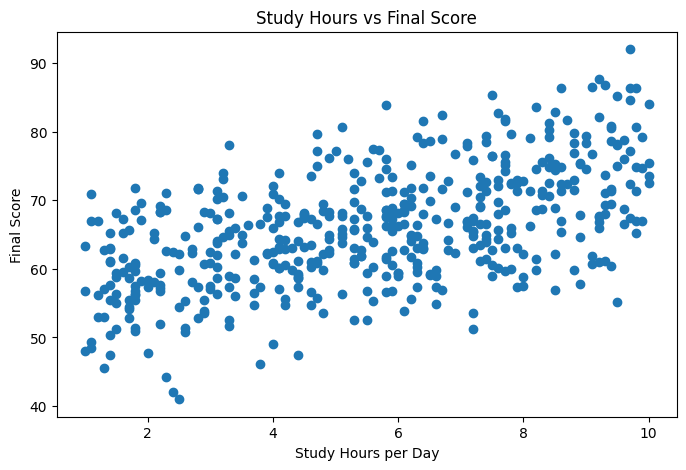

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(df["study_hours"], df["final_score"])

plt.xlabel("Study Hours per Day")
plt.ylabel("Final Score")
plt.title("Study Hours vs Final Score")

plt.show()

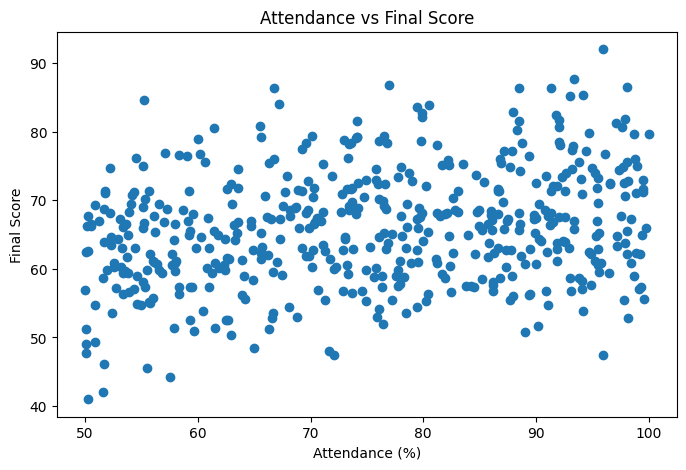

In [11]:
plt.figure(figsize=(8, 5))

plt.scatter(df["attendance"], df["final_score"])

plt.xlabel("Attendance (%)")
plt.ylabel("Final Score")
plt.title("Attendance vs Final Score")

plt.show()

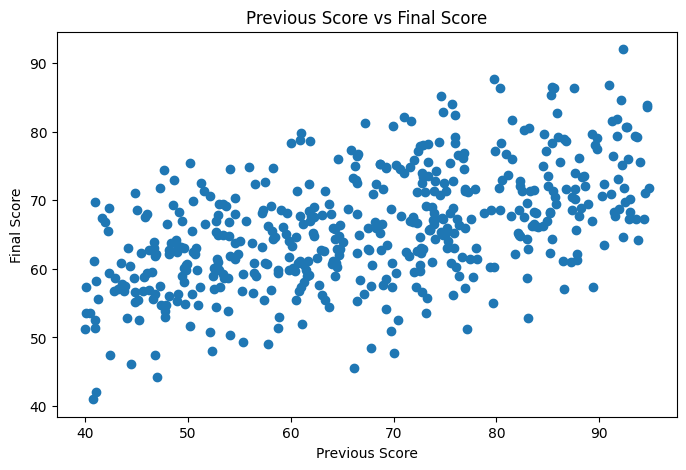

In [12]:
plt.figure(figsize=(8, 5))

plt.scatter(df["previous_score"], df["final_score"])

plt.xlabel("Previous Score")
plt.ylabel("Final Score")
plt.title("Previous Score vs Final Score")

plt.show()

In [13]:
correlation = df.corr(numeric_only=True)

correlation["final_score"].sort_values(ascending=False)

,final_score
final_score,1.000000
study_hours,0.559307
previous_score,0.536412
assignment_score,0.530479
attendance,0.258042
sleep_hours,0.157165
student_id,0.008803
age,0.004454
internet_hours,-0.172811


In [14]:
X = df.drop(columns=["student_id", "final_score"])
y = df["final_score"]

print("Features:")
print(X.columns)

print("\nTarget:")
print(y.name)

Features:
Index(['age', 'study_hours', 'attendance', 'previous_score',
       'assignment_score', 'sleep_hours', 'internet_hours'],
      dtype='object')

Target:
final_score


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (400, 7)
Testing data: (100, 7)


In [16]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!
